
Initial Scenario for FEW Model

1. Choose between utility water and an alternate water technology

2. Choose between utility energy and an alternate energy technology

3. Choose between 2 different crops

All variables dependant on water

Water informs the yields for the crops

Water informs how much energy is needed


In [1]:
from pyomo.environ import *
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# Matplotlib documentation: https://matplotlib.org/tutorials/introductory/pyplot.html
# Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

In [2]:
#parameters
#Precipatation
p = 0.254
#Price of Crop 1
pc1 = 200
#Price of Crop 2
pc2 = 250
#Price of Utility Water
puw = 1
#Price of Utility Electricity
pue = 0.12
#Unit Cost of Alternative Electricity
pae = 0
#Unit Cost of Alternative Water
paw = 2
#Capital Cost of Alternative Energy
ccae = 1000
#Capital Cost of Alternative Water
ccaw = 1000
#Big M
MM = 999999
#Area
A = 1

In [3]:
# create a model
model = ConcreteModel()

# declare decision variables
#Utility Water
model.uw = Var(domain=NonNegativeReals)
#Utility Energy
model.ue = Var(domain=NonNegativeReals)

#Alternative Water
model.aw = Var(domain=NonNegativeReals)
#Alternative Energy
model.ae = Var(domain=NonNegativeReals)
#Total Water
model.tw = Var(domain=NonNegativeReals)
#Total Energy
model.te = Var(domain=NonNegativeReals)
#Yield Crop 1
model.yc1 = Var(domain=NonNegativeReals)
#Yield Crop 2
model.yc2 = Var(domain=NonNegativeReals)
#Binary Decision to Plant Crop 1
model.bcc1 = Var(domain=Binary)
#Binary Decision to Plant Crop 2
model.bcc2 = Var(domain=Binary)
#Investment Decsion in Alternative Energy
model.iae = Var(domain=Binary)
#Investment Decision in Alternative Water
model.iaw = Var(domain=Binary)


In [4]:
# declare objective
model.profit = Objective(
    expr = (model.yc1*pc1 + model.yc2*pc2 - puw*model.uw - pue*model.ue - paw*model.aw - pae*model.ae
            - ccae*model.iae - ccaw*model.iaw)*A,
    sense = maximize)

# declare constraints
#Total water is sum of all water sources including precipitation
model.waterbalance = Constraint(expr = model.uw + model.aw + p == model.tw)

#Total Energy is sum of all energy sources
model.energybalance = Constraint(expr = model.ue + model.ae == model.te)

#Need 0.383 kWh / m^3 of water
model.waterenergyconv = Constraint(expr = 0.383*(model.uw + model.aw) == model.te)

#Yield Function for Crop 1
model.yieldcrop1 = Constraint(expr = -21.84*model.tw**2 + 32.9*model.tw - 5.8556 >= model.yc1)

#Yield Function for Crop 2, made up function inspired by the first yield function
model.yieldcrop2 = Constraint(expr = -30*model.tw**2 + 40*model.tw - 5 >= model.yc2)

#Cannot use alternative energy unless it is invested in
model.invae = Constraint(expr = model.ae <= MM*model.iae)

#Cannot use alternative water unless it is invested in
model.invaw = Constraint(expr = model.aw <= MM*model.iaw)

#Cannot harvest crop 1 unless it is planted
model.invc1 = Constraint(expr = model.yc1 <= MM*model.bcc1)

#Cannot harvest crop 2 unless it is planted
model.invc2 = Constraint(expr = model.yc2 <= MM*model.bcc2)

#Can only choose to plant one crop
model.cc = Constraint(expr = model.bcc1 + model.bcc2 <= 1)

#Constraint on Utility Water (10, 0.3, 10, 0.005,0.005)
model.limitedwater = Constraint(expr = model.uw <= 0.005)

#Constraint on Utility Electricity (10, 0.1, 0.005,10,0.005)
model.limitedelectricity = Constraint(expr = model.ue <= 0.005)


In [5]:
# solve
SolverFactory('gurobi').solve(model).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: x13
  Lower bound: 836.8872701766325
  Upper bound: 836.8872701766325
  Number of objectives: 1
  Number of constraints: 13
  Number of variables: 13
  Number of binary variables: 4
  Number of integer variables: 4
  Number of continuous variables: 9
  Number of nonzeros: 22
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Return code: 0
  Message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Termination condition: optimal
  Termination message: Model was solv

In [6]:
#Solutions of interest

print("Profit = ", model.profit(), "$")
print("Yield C1 = ", model.yc1(), " tonnes of crop 1 / acre")
print("Yield C2 = ", model.yc2(), " tonnes of crop 2 / acre")
print("Utility Water Used = ", model.uw(), " m^3/acre utility water")
print("Alternate Water Used = ", model.aw(), " m^3/acre alternate water")
print("Utility Energy Used = ", model.ue(), " kWh/acre utility energy")
print("Alternate Energy Used = ", model.ae(), " kWh/acre alternate energy")

Profit =  836.8872701766326 $
Yield C1 =  0.0  tonnes of crop 1 / acre
Yield C2 =  3.3475699999065403  tonnes of crop 2 / acre
Utility Water Used =  0.00500000000240336  m^3/acre utility water
Alternate Water Used =  0.0  m^3/acre alternate water
Utility Energy Used =  0.001915000000920486  kWh/acre utility energy
Alternate Energy Used =  0.0  kWh/acre alternate energy


In [52]:
# Make data frame from variables
sim_count = 1

DF = pd.DataFrame()
for v in model.component_objects(Var,active=True):
    for index in v:
       DF.at[index, v.name] = value(v[index])
    
DF.index = [sim_count]
DF

,uw,ue,aw,ae,tw,te,yc1,yc2,bcc1,bcc2,iae,iaw
1,0.005,0.001915,0.0,0.0,0.259,0.001915,0.0,3.34757,0.0,1.0,0.0,0.0


<AxesSubplot:>

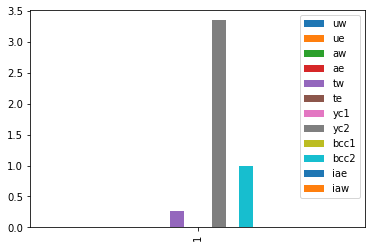

In [55]:
DF.plot.bar()

Int64Index([1], dtype='int64')

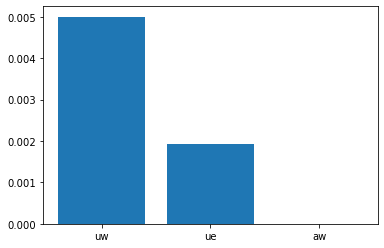

In [53]:
# One way to plot a few results using .iloc for indexing

plt.bar(['uw','ue','aw'],DF.iloc[0,0:3])


<AxesSubplot:title={'center':'Results Values'}, xlabel='Variable', ylabel='Value'>

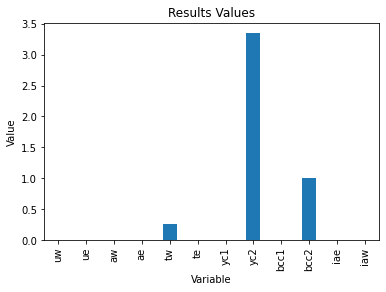

In [54]:
DF.iloc[0,0:len(DF.columns)].plot.bar(xlabel = 'Variable', ylabel = 'Value', title = 'Results Values')

<BarContainer object of 3 artists>

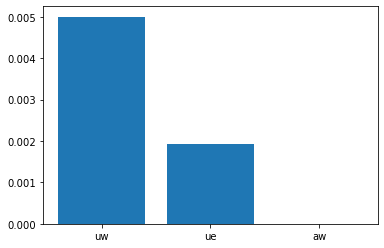

In [43]:
df2 = pd.DataFrame(np.random.rand(10, 4), columns=['a', 'b', 'c', 'd'])

df2

,a,b,c,d
0,0.649287,0.137913,0.566643,0.018467
1,0.240465,0.329754,0.699210,0.895333
2,0.780778,0.792212,0.215459,0.199695
3,0.411949,0.115020,0.699335,0.510653
4,0.961991,0.950421,0.161118,0.219882
5,0.850500,0.638519,0.091093,0.524329
6,0.992619,0.378313,0.800142,0.740345
7,0.379767,0.471167,0.162426,0.829120
8,0.926437,0.250707,0.628196,0.290123
9,0.039648,0.031929,0.890276,0.315954


<AxesSubplot:>

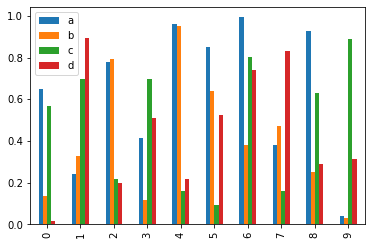

In [44]:
df2.plot.bar()

<AxesSubplot:>

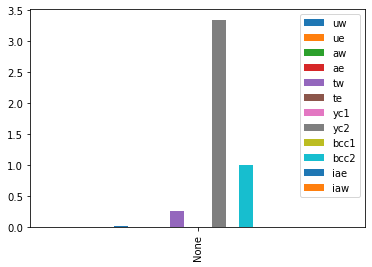

In [45]:
DF.plot.bar()

In [1]:
climate = ['C1', 'C2', 'C3']
season = ['S1', 'S2', 'S3', 'S4', 'S5']
option = ['O1', 'O2', 'O3']

indicies = [(x,y,z) for x in climate for y in season for z in option]

rain = {}

for i in range(len(indicies)):
    rain[indicies[i]] = precip[i]/4

rain

samples = len(indicies)

c1_coef = 1
c2_coef = 1
c3_coef = 1

NameError: name 'precip' is not defined

In [ ]:
m = Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

#alt_water = m.addVar(name = 'alt_water') # cm of depth

c1 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c1')
c2 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c2')
c3 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c3')


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(climate, season, option, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(climate, season, option, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(climate, season, option,name = 'yield') # tonne/ha
profit = m.addVars(climate, season, option, name = 'profit') # $

profit_c1 = m.addVars(season, option, obj = c1_coef/samples, name = 'profit_c1') 
profit_c2 = m.addVars(season, option, obj = c2_coef/samples, name = 'profit_c2') 
profit_c3 = m.addVars(season, option, obj = c3_coef/samples, name = 'profit_c3') 

#Maybe add a new profit variable that is the sum of the profit based on climate for easy coefficients



# Objective

m.addConstrs( (profit[k,i,j] == crop_yield[k,i,j] * ha * price +
              -alt_water_c1 * cost_alt_water * c1 +
              -alt_water_c2 * cost_alt_water * c2 +
              -alt_water_c3 * cost_alt_water * c3 +
              -irrigation_water[k,i,j] * cost_irrigation_water
             for k in climate for i in season for j in option)
            ,name = 'profit')

m.addConstrs( (profit['C1',i,j] == profit_c1[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')

m.addConstrs( (profit['C2',i,j] == profit_c2[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')

m.addConstrs( (profit['C3',i,j] == profit_c3[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')
# Set Constraints



m.addConstrs( (rain[k,i,j] + c1*alt_water_c1 + c2*alt_water_c2 + c3*alt_water_c3 + irrigation_water[k,i,j] >= water[k,i,j] 
              for k in climate for i in season for j in option)
            ,name = 'water' )

# Add constraints for each climate Scenario different precipitation, irrigation, and total water variables 
# m.addConstrs( (rain(i,j,k)*c1 + rain('C2',j,k)*c2 + rain('C3',j,k)   ))


m.addConstr( (c1 + c2 +c3 == 1), name = 'pick_climate')

for k in climate:
    for i in season :
        for j in option:
            m.addQConstr( (crop_yield[k,i,j] <= -3.350 + 0.2064*water[k,i,j]  - 0.0014*water[k,i,j]*water[k,i,j]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[k,i,j]  * salt_conc_water + 0.033 * water[k,i,j]  * salt_conc 
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();


